In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os

DATASET_ZIP = "/content/drive/MyDrive/FETAL_DATASET.zip"
DATASET_DIR = "/content/drive/MyDrive/FETAL_DATASET"

# Unzip only if the folder does not exist
if not os.path.exists(DATASET_DIR):
    print("Extracting dataset...")
    !unzip "$DATASET_ZIP" -d "/content/drive/MyDrive/"
else:
    print("Dataset already exists. Skipping unzip.")


Extracting dataset...
Archive:  /content/drive/MyDrive/FETAL_DATASET.zip
replace /content/drive/MyDrive/dataset/archive.zip? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: /content/drive/MyDrive/dataset/archive.zip  
  inflating: /content/drive/MyDrive/dataset/Classification/External Test images/Patient01600_Plane6_1_of_8.png  
  inflating: /content/drive/MyDrive/dataset/Classification/External Test images/Patient01606_Plane3_2_of_5.png  
  inflating: /content/drive/MyDrive/dataset/Classification/External Test images/Patient01612_Plane1_19_of_21.png  
  inflating: /content/drive/MyDrive/dataset/Classification/External Test images/Patient01616_Plane6_1_of_1.png  
  inflating: /content/drive/MyDrive/dataset/Classification/External Test images/Patient01623_Plane4_2_of_3.png  
  inflating: /content/drive/MyDrive/dataset/Classification/External Test images/Patient01630_Plane1_1_of_3.png  
  inflating: /content/drive/MyDrive/dataset/Classification/External Test images/Patient01631_Plan

In [3]:
IMAGE_DIR = os.path.join(DATASET_DIR, "Classification/images")
CSV_PATH  = os.path.join(DATASET_DIR, "Classification/image_label.csv")


In [4]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


In [5]:
!find . -maxdepth 4 -type f -name "image_label.csv"


In [6]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/dataset/Classification/image_label.csv")
df.head()

,Image_name,Plane
0,Patient01018_Plane3_2_of_3,Fetal brain
1,Patient00770_Plane3_2_of_3,Fetal brain
2,Patient00853_Plane3_1_of_3,Fetal brain
3,Patient01230_Plane3_5_of_5,Fetal brain
4,Patient01494_Plane3_3_of_4,Fetal brain


In [7]:
!ls



drive  sample_data


In [8]:
!ls dataset


ls: cannot access 'dataset': No such file or directory


In [9]:
!ls dataset/Classification


ls: cannot access 'dataset/Classification': No such file or directory


In [10]:
print(df.columns)


Index(['Image_name', 'Plane'], dtype='object')


In [11]:
# Normalize column names
df.columns = df.columns.str.strip().str.lower()
df.rename(columns={'image_name':'image', 'plane':'label'}, inplace=True)

# Check the result
df.head()


,image,label
0,Patient01018_Plane3_2_of_3,Fetal brain
1,Patient00770_Plane3_2_of_3,Fetal brain
2,Patient00853_Plane3_1_of_3,Fetal brain
3,Patient01230_Plane3_5_of_5,Fetal brain
4,Patient01494_Plane3_3_of_4,Fetal brain


In [12]:
# Check first few image names
df['image'].head()

# Check folder contents
!ls dataset/Classification/images | head


ls: cannot access 'dataset/Classification/images': No such file or directory


In [13]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42
)


In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

# Data augmentation + normalization
datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixel values
    rotation_range=15,       # Random rotation
    zoom_range=0.1,          # Random zoom
    horizontal_flip=True     # Random horizontal flip
)

In [15]:
# Training generator
train_gen = datagen.flow_from_dataframe(
    train_df,
    directory="dataset/Classification/images", # Corrected directory
    x_col="image",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Validation generator
val_gen = datagen.flow_from_dataframe(
    val_df,
    directory="dataset/Classification/images", # Corrected directory
    x_col="image",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Test generator
test_gen = datagen.flow_from_dataframe(
    test_df,
    directory="dataset/Classification/images", # Corrected directory
    x_col="image",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 0 validated image filenames belonging to 0 classes.
Found 0 validated image filenames belonging to 0 classes.
Found 0 validated image filenames belonging to 0 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 1152 invalid image filename(s) in x_col="image". These filename(s) will be ignored.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 247 invalid image filename(s) in x_col="image". These filename(s) will be ignored.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 247 invalid image filename(s) in x_col="image". These filename(s) will be ignored.
  warnings.warn(


In [16]:
!ls "dataset/Classification/image_label.csv" | head


ls: cannot access 'dataset/Classification/image_label.csv': No such file or directory


In [17]:
import pandas as pd
import os

# Load CSV
df = pd.read_csv("/content/drive/MyDrive/dataset/Classification/image_label.csv")

# Normalize column names
df.columns = df.columns.str.strip().str.lower()
df.rename(columns={'image_name':'image', 'plane':'label'}, inplace=True)

# Clean label names
df['label'] = df['label'].str.lower().str.strip()

# Check
print(df.head())
print(df['label'].value_counts())

                        image        label
0  Patient01018_Plane3_2_of_3  fetal brain
1  Patient00770_Plane3_2_of_3  fetal brain
2  Patient00853_Plane3_1_of_3  fetal brain
3  Patient01230_Plane3_5_of_5  fetal brain
4  Patient01494_Plane3_3_of_4  fetal brain
label
fetal brain      556
fetal thorax     451
fetal abdomen    339
fetal femur      300
Name: count, dtype: int64


In [18]:
# Add .png extension to image names
df['image'] = df['image'].str.strip() + ".png"


In [19]:
IMAGE_DIR = "dataset/Classification/External Test images"

existing = df['image'].apply(lambda x: os.path.exists(os.path.join(IMAGE_DIR, x)))
print("Valid images found:", existing.sum())
print("Invalid images:", len(df) - existing.sum())



Valid images found: 0
Invalid images: 1646


In [20]:
import os

IMAGE_DIR = "/content/drive/MyDrive/dataset/Classification/images"
all_files = os.listdir(IMAGE_DIR)
print("Number of files in folder:", len(all_files))
print("First 10 files:", all_files[:10])

Number of files in folder: 327
First 10 files: ['Patient00913_Plane3_3_of_3.png', 'Patient00914_Plane3_3_of_4.png', 'Patient00917_Plane2_1_of_1.png', 'Patient00917_Plane5_2_of_2.png', 'Patient00917_Plane6_2_of_3.png', 'Patient00918_Plane6_1_of_4.png', 'Patient00919_Plane6_2_of_8.png', 'Patient00919_Plane6_5_of_8.png', 'Patient00919_Plane6_6_of_8.png', 'Patient00919_Plane6_8_of_8.png']


In [21]:
import pandas as pd
import os

IMAGE_DIR = "/content/drive/MyDrive/dataset/Classification/images"  # main images folder

# Load CSV
df = pd.read_csv("/content/drive/MyDrive/dataset/Classification/image_label.csv")

# Normalize columns
df.columns = df.columns.str.strip().str.lower()
df.rename(columns={'image_name':'image', 'plane':'label'}, inplace=True)
df['label'] = df['label'].str.lower().str.strip()

# List all files in the images folder
all_files = os.listdir(IMAGE_DIR)

# Match CSV names to real files in folder (add extensions)
def match_file(name):
    for f in all_files:
        if f.startswith(name):
            return f
    return None

df['image'] = df['image'].apply(match_file)
df = df[df['image'].notnull()]  # keep only valid images

print("Total valid images:", len(df))
df.head()

Total valid images: 327


,image,label
0,Patient01018_Plane3_2_of_3.png,fetal brain
13,Patient01105_Plane3_5_of_5.png,fetal brain
14,Patient01096_Plane3_2_of_6.png,fetal brain
15,Patient01070_Plane3_4_of_6.png,fetal brain
16,Patient00986_Plane3_4_of_4.png,fetal brain


In [22]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42
)


In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)


In [24]:
train_gen = datagen.flow_from_dataframe(
    train_df,
    directory=IMAGE_DIR,
    x_col="image",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_gen = datagen.flow_from_dataframe(
    val_df,
    directory=IMAGE_DIR,
    x_col="image",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_gen = datagen.flow_from_dataframe(
    test_df,
    directory=IMAGE_DIR,
    x_col="image",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)


Found 228 validated image filenames belonging to 4 classes.
Found 49 validated image filenames belonging to 4 classes.
Found 50 validated image filenames belonging to 4 classes.


In [25]:
# Check one batch
x_batch, y_batch = next(train_gen)
print("Image batch shape:", x_batch.shape)
print("Label batch shape:", y_batch.shape)


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 4)


In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model = Sequential([
    Input(shape=(224, 224, 3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(4, activation='softmax')
])



In [27]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [28]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.2506 - loss: 1.7475 - val_accuracy: 0.3061 - val_loss: 1.3792
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 783ms/step - accuracy: 0.3080 - loss: 1.3753 - val_accuracy: 0.4898 - val_loss: 1.3344
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 749ms/step - accuracy: 0.4088 - loss: 1.3275 - val_accuracy: 0.5306 - val_loss: 1.2854
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 830ms/step - accuracy: 0.4097 - loss: 1.2542 - val_accuracy: 0.5918 - val_loss: 1.1849
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 743ms/step - accuracy: 0.5108 - loss: 1.1786 - val_accuracy: 0.5918 - val_loss: 1.1339
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 904ms/step - accuracy: 0.5475 - loss: 1.0926 - val_accuracy: 0.5510 - val_loss: 1.0975
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 664ms/step - accuracy: 0.5415 - loss: 1.0700 - val_accuracy: 0.6122 - val_loss: 1.0673
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 757ms/step - accuracy: 0.6389 - loss: 0.9575 - val_accuracy: 0.6327 - val_loss: 1

In [29]:
test_loss, test_acc = model.evaluate(test_gen)
print("Test Accuracy:", test_acc)


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.7433 - loss: 0.7535
Test Accuracy: 0.7400000095367432


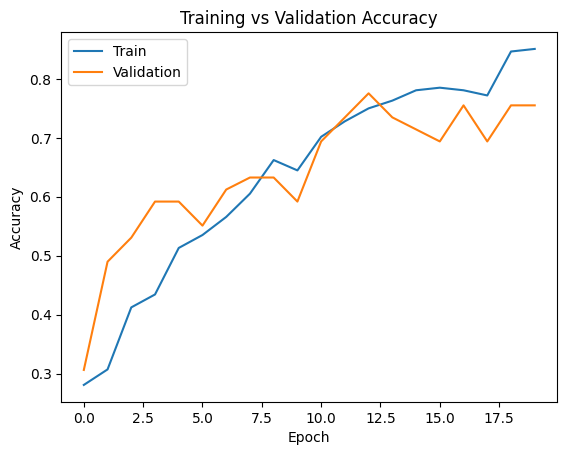

In [30]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend(["Train", "Validation"])
plt.show()


In [31]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Predictions
y_pred = model.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

# Class labels
class_labels = list(test_gen.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
print("Confusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 370ms/step
Confusion Matrix:
 [[ 8  1  0  1]
 [ 0 13  1  2]
 [ 4  0  5  0]
 [ 4  1  3  7]]

Classification Report:

               precision    recall  f1-score   support

fetal abdomen       0.50      0.80      0.62        10
  fetal brain       0.87      0.81      0.84        16
  fetal femur       0.56      0.56      0.56         9
 fetal thorax       0.70      0.47      0.56        15

     accuracy                           0.66        50
    macro avg       0.66      0.66      0.64        50
 weighted avg       0.69      0.66      0.66        50



In [34]:
train_files = set(train_df['image'].values)
val_files   = set(val_df['image'].values)
test_files  = set(test_df['image'].values)


In [35]:
print("Train ∩ Val overlap:", len(train_files & val_files))
print("Train ∩ Test overlap:", len(train_files & test_files))
print("Val ∩ Test overlap:", len(val_files & test_files))


Train ∩ Val overlap: 0
Train ∩ Test overlap: 0
Val ∩ Test overlap: 0
